In [1]:
import os
import random
import warnings
import io
import sys
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

import cv2
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("All imports loaded successfully.")

2026-04-04 19:43:47.505915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775331827.690609      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775331827.745605      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775331828.165553      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775331828.165592      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775331828.165595      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All imports loaded successfully.


In [2]:
DATA_DIR = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images"
CLASSES  = ["Parasitized", "Uninfected"]

total = 0
class_counts = {}

for cls in CLASSES:
    path = os.path.join(DATA_DIR, cls)
    images = [f for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[cls] = len(images)
    total += len(images)
    print(f"{cls}: {len(images)} images")

print(f"Total: {total} images")
print(f"Class balance: {class_counts['Parasitized']/total*100:.1f}% Parasitized / {class_counts['Uninfected']/total*100:.1f}% Uninfected")

Parasitized: 13779 images
Uninfected: 13779 images
Total: 27558 images
Class balance: 50.0% Parasitized / 50.0% Uninfected


EDA and Visualizations


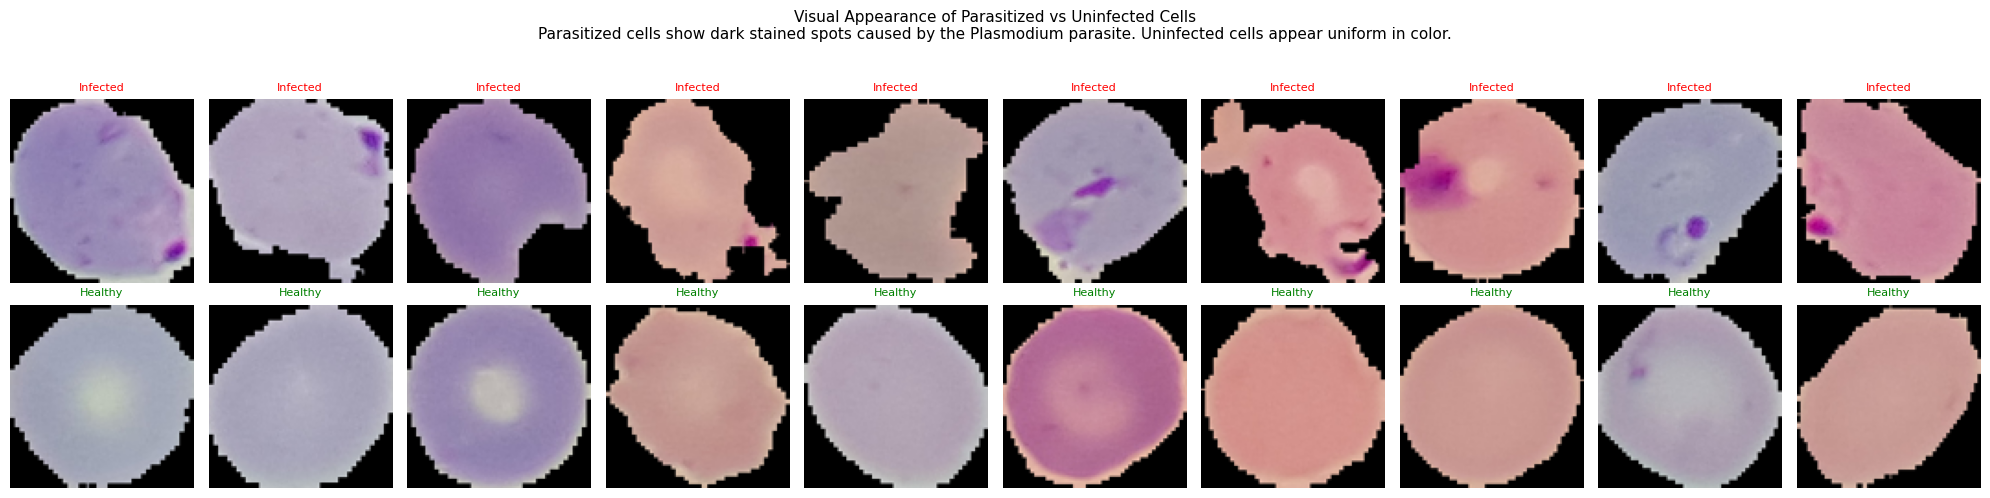

In [3]:
def load_sample_images(cls, n=10):
    path = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    sample = random.sample(files, n)
    images = [np.array(Image.open(os.path.join(path, f)).resize((100, 100))) for f in sample]
    return images

parasitized_samples = load_sample_images("Parasitized", 10)
uninfected_samples  = load_sample_images("Uninfected", 10)

# Visualization 1 - Visual appearance of each class
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle(
    "Visual Appearance of Parasitized vs Uninfected Cells\n"
    "Parasitized cells show dark stained spots caused by the Plasmodium parasite. "
    "Uninfected cells appear uniform in color.",
    fontsize=11, y=1.02
)

for col in range(10):
    axes[0, col].imshow(parasitized_samples[col])
    axes[0, col].set_title("Infected", fontsize=8, color='red')
    axes[0, col].axis('off')

    axes[1, col].imshow(uninfected_samples[col])
    axes[1, col].set_title("Healthy", fontsize=8, color='green')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig("visualization_1_cell_appearance.png", dpi=150, bbox_inches='tight')
plt.show()

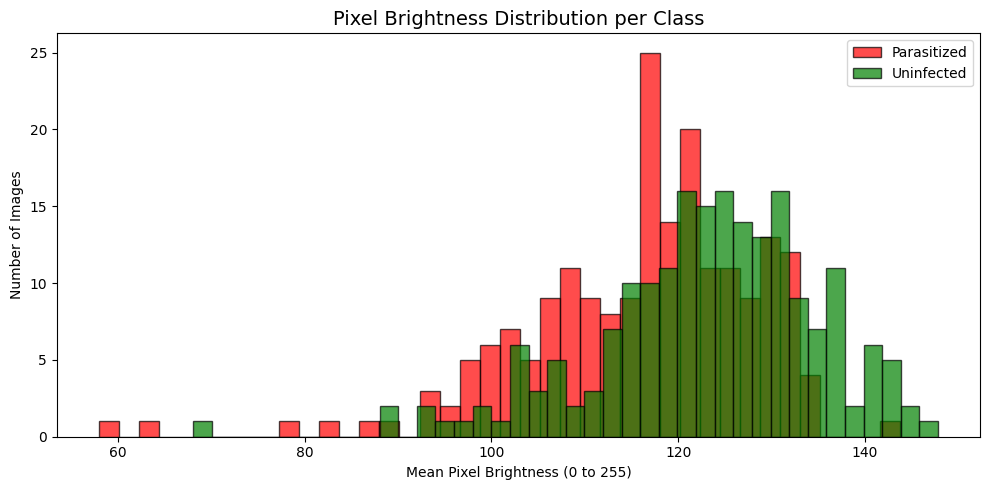

Interpretation:
Parasitized cells tend to be darker on average. This is because the
Plasmodium parasite absorbs the Giemsa stain used in lab slide preparation,
creating darker regions that lower the overall mean pixel value of the image.


In [4]:
# Visualization 2 - Pixel brightness distribution
def get_brightness(images):
    return [np.mean(img) for img in images]

p_brightness = get_brightness(load_sample_images("Parasitized", 200))
u_brightness = get_brightness(load_sample_images("Uninfected", 200))

plt.figure(figsize=(10, 5))
plt.hist(p_brightness, bins=40, alpha=0.7, color='red',   label='Parasitized', edgecolor='black')
plt.hist(u_brightness, bins=40, alpha=0.7, color='green', label='Uninfected',  edgecolor='black')
plt.title("Pixel Brightness Distribution per Class", fontsize=14)
plt.xlabel("Mean Pixel Brightness (0 to 255)")
plt.ylabel("Number of Images")
plt.legend()
plt.tight_layout()
plt.savefig("visualization_2_brightness.png", dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation:")
print("Parasitized cells tend to be darker on average. This is because the")
print("Plasmodium parasite absorbs the Giemsa stain used in lab slide preparation,")
print("creating darker regions that lower the overall mean pixel value of the image.")

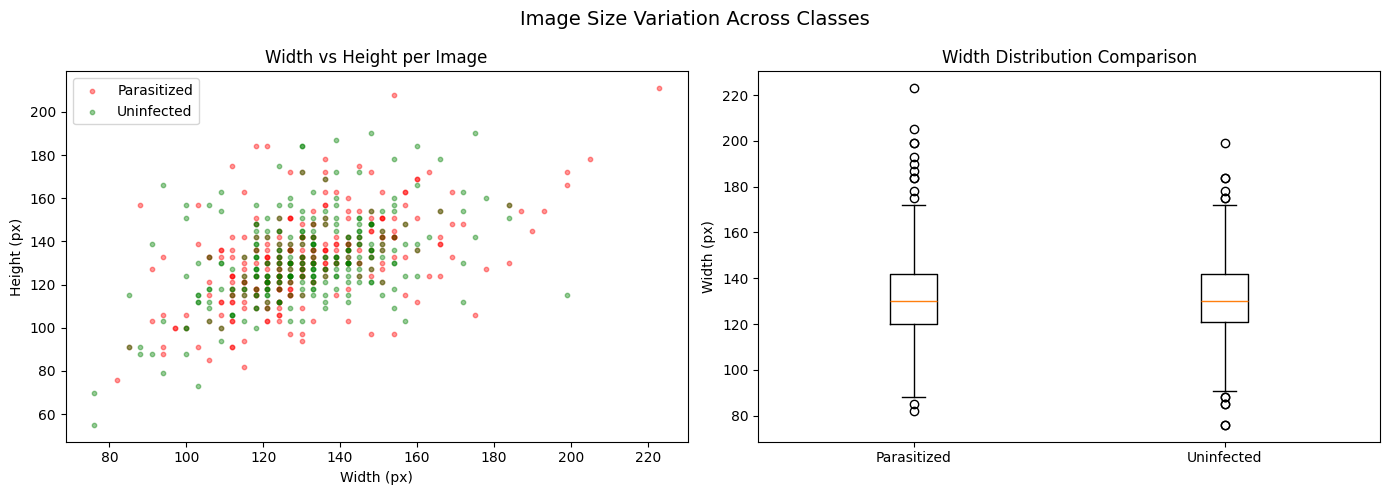

Interpretation:
Images in this dataset are not a fixed size — they vary in both width and height.
This is typical of microscopy images captured under different zoom levels or
camera settings. Resizing all images to a fixed dimension before training
is therefore not just a convenience but a necessity for model consistency.


In [5]:
# Visualization 3 - Image size variation
def get_sizes(cls, n=300):
    path = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    files = random.sample(files, n)
    sizes = []
    for f in files:
        img = Image.open(os.path.join(path, f))
        sizes.append(img.size)
    return sizes

p_sizes = get_sizes("Parasitized")
u_sizes = get_sizes("Uninfected")

p_widths  = [s[0] for s in p_sizes]
u_widths  = [s[0] for s in u_sizes]
p_heights = [s[1] for s in p_sizes]
u_heights = [s[1] for s in u_sizes]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Image Size Variation Across Classes", fontsize=14)

axes[0].scatter(p_widths, p_heights, alpha=0.4, color='red',   label='Parasitized', s=10)
axes[0].scatter(u_widths, u_heights, alpha=0.4, color='green', label='Uninfected',  s=10)
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title("Width vs Height per Image")
axes[0].legend()

axes[1].boxplot([p_widths, u_widths], labels=['Parasitized', 'Uninfected'])
axes[1].set_title("Width Distribution Comparison")
axes[1].set_ylabel("Width (px)")

plt.tight_layout()
plt.savefig("visualization_3_image_sizes.png", dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation:")
print("Images in this dataset are not a fixed size — they vary in both width and height.")
print("This is typical of microscopy images captured under different zoom levels or")
print("camera settings. Resizing all images to a fixed dimension before training")
print("is therefore not just a convenience but a necessity for model consistency.")

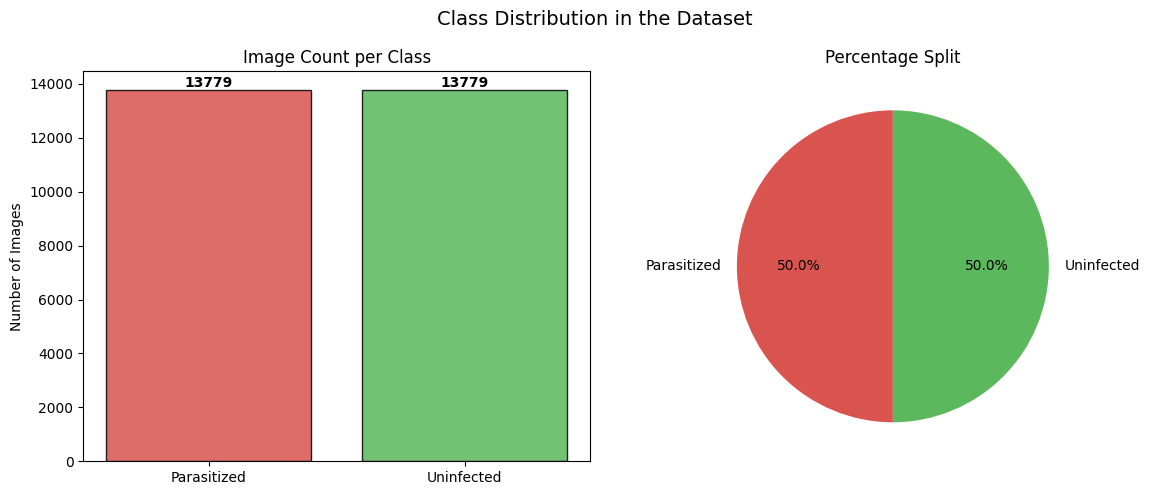

Interpretation:
The dataset is evenly balanced with roughly 13,779 images per class.
This means the model cannot achieve high accuracy by simply predicting
one class all the time. Standard metrics like accuracy are therefore reliable here.


In [6]:
# Visualization 4 - Class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Class Distribution in the Dataset", fontsize=14)

axes[0].bar(
    CLASSES,
    [class_counts[c] for c in CLASSES],
    color=['#d9534f', '#5cb85c'],
    edgecolor='black',
    alpha=0.85
)
axes[0].set_title("Image Count per Class")
axes[0].set_ylabel("Number of Images")
for i, cls in enumerate(CLASSES):
    axes[0].text(i, class_counts[cls] + 100, str(class_counts[cls]), ha='center', fontweight='bold')

axes[1].pie(
    [class_counts[c] for c in CLASSES],
    labels=CLASSES,
    colors=['#d9534f', '#5cb85c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title("Percentage Split")

plt.tight_layout()
plt.savefig("visualization_4_class_balance.png", dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation:")
print("The dataset is evenly balanced with roughly 13,779 images per class.")
print("This means the model cannot achieve high accuracy by simply predicting")
print("one class all the time. Standard metrics like accuracy are therefore reliable here.")

---

## Section 4 — Data Preprocessing

Raw images cannot be fed directly into a machine learning model. The following preprocessing steps are applied:

- **Resizing** — all images are resized to **64 x 64 pixels** to ensure consistent input dimensions
- **Normalization** — pixel values are scaled from [0, 255] to [0, 1] to help models converge faster
- **Train/Test Split** — the dataset is split **80% training / 20% testing**, stratified to preserve class balance
- **Flattening** — for traditional ML models, each image is flattened into a 1D vector of 12,288 features (64 x 64 x 3)

In [7]:
# Configuration
IMG_SIZE    = (64, 64)   # resize all images to 64x64
BATCH_SIZE  = 32
RANDOM_SEED = 42
TEST_SPLIT  = 0.2

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [8]:
# Load and preprocess all images into numpy arrays
def load_dataset(data_dir, img_size):
    images = []
    labels = []

    for label, cls in enumerate(CLASSES):
        class_path = os.path.join(data_dir, cls)
        files = [f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

        print(f"Loading {cls}...")

        for fname in files:
            img_path = os.path.join(class_path, fname)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize(img_size)
                img_array = np.array(img) / 255.0   # normalize to [0, 1]
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Skipped {fname}: {e}")

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    print(f"\nDataset loaded.")
    print(f"Images shape : {images.shape}")
    print(f"Labels shape : {labels.shape}")
    print(f"Parasitized  = 0, Uninfected = 1")

    return images, labels

images, labels = load_dataset(DATA_DIR, IMG_SIZE)

Loading Parasitized...
Loading Uninfected...

Dataset loaded.
Images shape : (27558, 64, 64, 3)
Labels shape : (27558,)
Parasitized  = 0, Uninfected = 1


In [9]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    images, labels,
    test_size=TEST_SPLIT,
    random_state=RANDOM_SEED,
    stratify=labels   # ensures balanced split across both classes
)

print(f"Training set   : {X_train.shape[0]} images")
print(f"Test set       : {X_test.shape[0]} images")
print(f"Train positives: {np.sum(y_train == 0)} Parasitized / {np.sum(y_train == 1)} Uninfected")
print(f"Test positives : {np.sum(y_test == 0)} Parasitized / {np.sum(y_test == 1)} Uninfected")

Training set   : 22046 images
Test set       : 5512 images
Train positives: 11023 Parasitized / 11023 Uninfected
Test positives : 2756 Parasitized / 2756 Uninfected


In [10]:
# Flatten images for traditional ML models
# SVM and Random Forest expect 1D feature vectors, not 3D image arrays
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print(f"Flattened training shape : {X_train_flat.shape}")
print(f"Flattened test shape     : {X_test_flat.shape}")
print("Traditional ML data is ready.")

Flattened training shape : (22046, 12288)
Flattened test shape     : (5512, 12288)
Traditional ML data is ready.


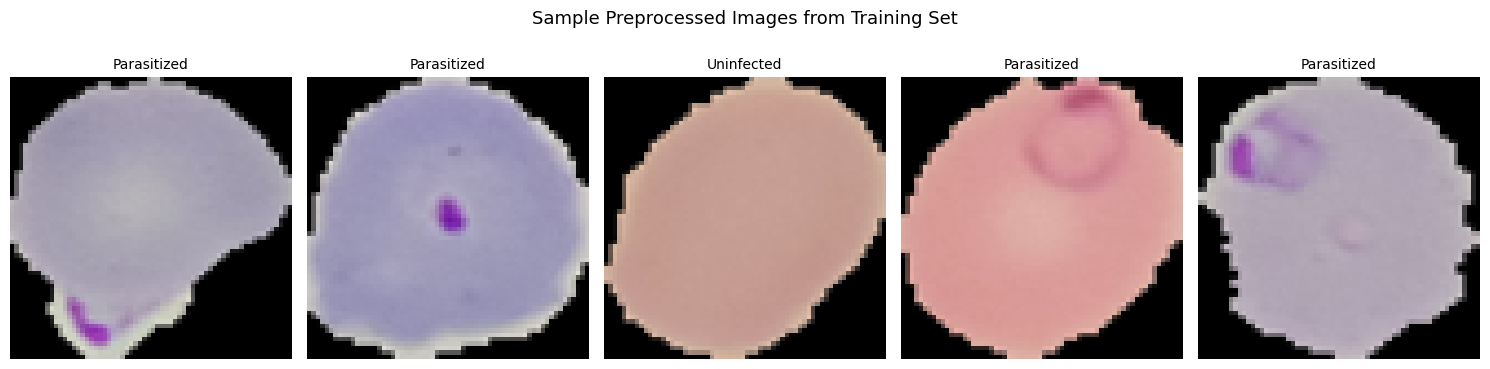

In [11]:
# Verify a sample image after preprocessing
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle("Sample Preprocessed Images from Training Set", fontsize=13)

for i in range(5):
    axes[i].imshow(X_train[i])
    label_name = "Parasitized" if y_train[i] == 0 else "Uninfected"
    axes[i].set_title(label_name, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("preprocessing_sample.png", dpi=150, bbox_inches='tight')
plt.show()


---

## Section 5 — Traditional Machine Learning Models

Two traditional machine learning models are trained on the flattened image data:

- **Random Forest** — an ensemble of decision trees that votes on the final prediction
- **Support Vector Machine (SVM)** — finds the optimal boundary between the two classes

Since these models cannot process raw image arrays, each image is represented as a flat vector of pixel values with a length of 12,288 (64 x 64 x 3).

In [12]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)

### Random Forest

In [13]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_model.fit(X_train_flat, y_train)
rf_preds = rf_model.predict(X_test_flat)

print("Random Forest Results")
print(classification_report(y_test, rf_preds, target_names=CLASSES))

Random Forest Results
              precision    recall  f1-score   support

 Parasitized       0.79      0.85      0.82      2756
  Uninfected       0.83      0.78      0.81      2756

    accuracy                           0.81      5512
   macro avg       0.81      0.81      0.81      5512
weighted avg       0.81      0.81      0.81      5512



### Support Vector Machine

In [14]:
SAMPLE_SIZE = 5000

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_flat, y_train,
    train_size=SAMPLE_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_train
)

svm_model = SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED)
svm_model.fit(X_train_sample, y_train_sample)
svm_preds = svm_model.predict(X_test_flat)

print("SVM Results")
print(classification_report(y_test, svm_preds, target_names=CLASSES))

SVM Results
              precision    recall  f1-score   support

 Parasitized       0.71      0.69      0.70      2756
  Uninfected       0.70      0.72      0.71      2756

    accuracy                           0.71      5512
   macro avg       0.71      0.71      0.71      5512
weighted avg       0.71      0.71      0.71      5512



### Confusion Matrices

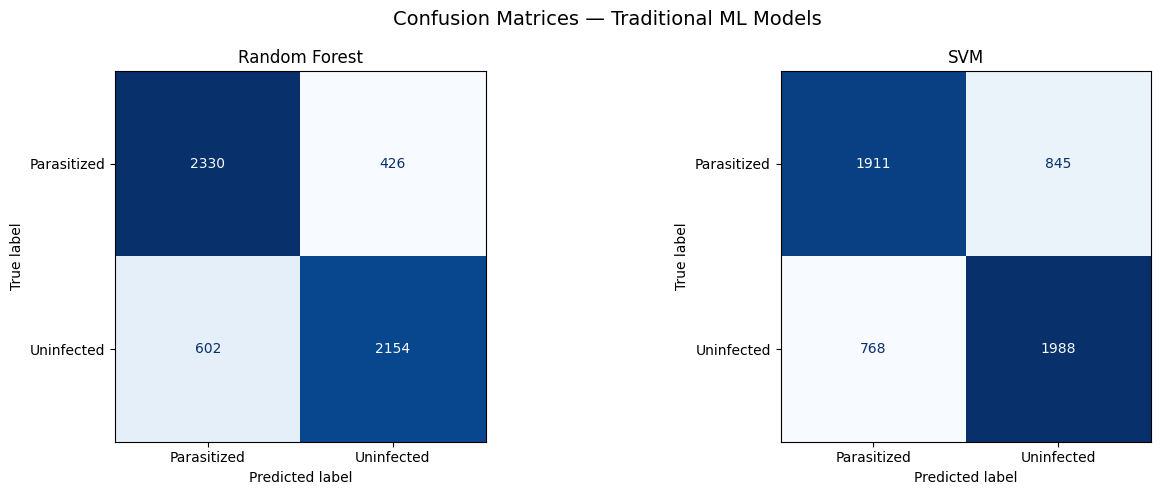

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrices — Traditional ML Models", fontsize=14)

for ax, preds, title in zip(axes, [rf_preds, svm_preds], ["Random Forest", "SVM"]):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.savefig("traditional_ml_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

### ROC Curves

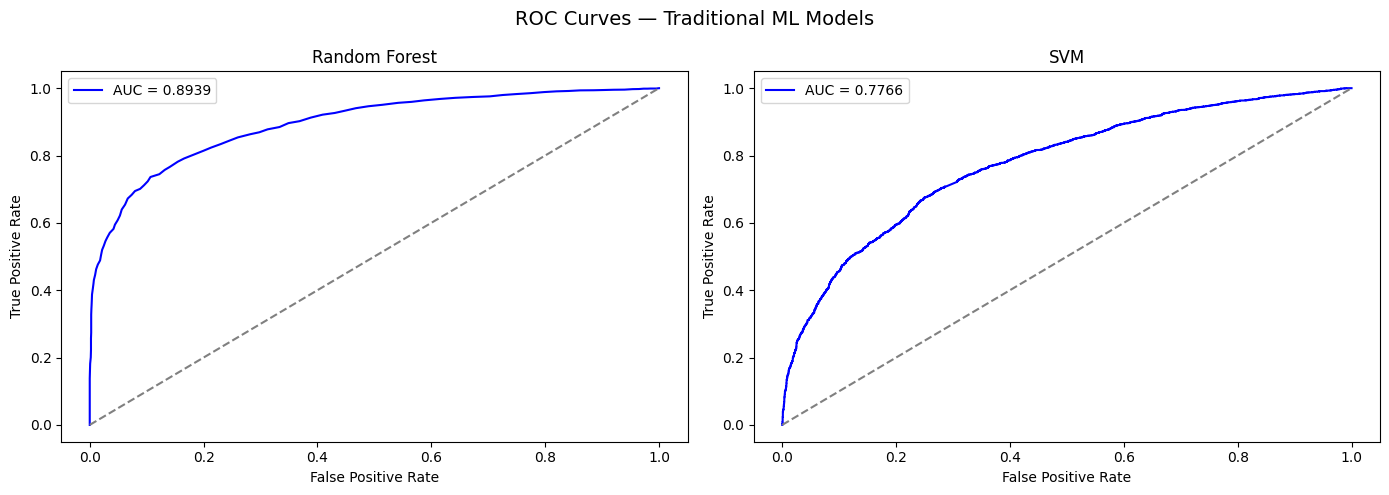

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ROC Curves — Traditional ML Models", fontsize=14)

for ax, model, title in zip(axes, [rf_model, svm_model], ["Random Forest", "SVM"]):
    probs = model.predict_proba(X_test_flat)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig("traditional_ml_roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()



## Section 6 — Deep Learning Models

Three deep learning approaches are implemented and compared:

- **Sequential CNN** — a straightforward convolutional neural network built using the Keras Sequential API
- **Functional API CNN** — the same architecture built using the Keras Functional API, demonstrating flexibility for more complex model designs
- **Transfer Learning with VGG16** — a pretrained VGG16 model fine-tuned on the malaria dataset, leveraging features learned from ImageNet

### Data Preparation for Deep Learning

In [17]:
# Image data generators with augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

test_datagen = ImageDataGenerator()

# Convert labels to float32 for compatibility
y_train_dl = y_train.astype(np.float32)
y_test_dl  = y_test.astype(np.float32)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Input shape      : {X_train.shape[1:]}")

Training samples : 22046
Test samples     : 5512
Input shape      : (64, 64, 3)


### Sequential CNN

In [18]:
def build_sequential_cnn(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),
        layers.BatchNormalization(),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.BatchNormalization(),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.BatchNormalization(),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ], name="Sequential_CNN")

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

sequential_cnn = build_sequential_cnn((64, 64, 3))
sequential_cnn.summary()

I0000 00:00:1775333493.879064      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "Sequential_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,305 (4.86 MB)

 Trainable params: 1,273,857 (4.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

sequential_history = sequential_cnn.fit(
    X_train, y_train_dl,
    validation_split=0.2,
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


I0000 00:00:1775333499.510677     152 service.cc:152] XLA service 0x7b46a00121b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775333499.510713     152 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775333500.065636     152 cuda_dnn.cc:529] Loaded cuDNN version 91002


 32/552 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5867 - loss: 1.3289

I0000 00:00:1775333503.585717     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


552/552 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.7877 - loss: 0.5775 - val_accuracy: 0.5238 - val_loss: 1.0969 - learning_rate: 0.0010
Epoch 2/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9388 - loss: 0.1868 - val_accuracy: 0.9356 - val_loss: 0.2202 - learning_rate: 0.0010
Epoch 3/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9461 - loss: 0.1634 - val_accuracy: 0.9510 - val_loss: 0.1600 - learning_rate: 0.0010
Epoch 4/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9479 - loss: 0.1604 - val_accuracy: 0.9444 - val_loss: 0.2197 - learning_rate: 0.0010
Epoch 5/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9556 - loss: 0.1393 - val_accuracy: 0.9447 - val_loss: 0.1724 - learning_rate: 0.0010
Epoch 6/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9596 - loss: 0.1201 - val_accuracy: 0.9558 - val_loss: 0.1593 - learning_rate: 0.0010
Epoch 7/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9601 - loss: 0.1211 - val_accur

### Functional API CNN

In [20]:
def build_functional_cnn(input_shape):
    inputs = Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs, name="Functional_CNN")
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

functional_cnn = build_functional_cnn((64, 64, 3))
functional_cnn.summary()

Model: "Functional_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,305 (4.86 MB)

 Trainable params: 1,273,857 (4.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
functional_history = functional_cnn.fit(
    X_train, y_train_dl,
    validation_split=0.2,
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7687 - loss: 0.6010 - val_accuracy: 0.8460 - val_loss: 0.3345 - learning_rate: 0.0010
Epoch 2/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9369 - loss: 0.1940 - val_accuracy: 0.9494 - val_loss: 0.1696 - learning_rate: 0.0010
Epoch 3/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9506 - loss: 0.1530 - val_accuracy: 0.9374 - val_loss: 0.1749 - learning_rate: 0.0010
Epoch 4/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9526 - loss: 0.1413 - val_accuracy: 0.9546 - val_loss: 0.1607 - learning_rate: 0.0010
Epoch 5/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9516 - loss: 0.1511 - val_accuracy: 0.9551 - val_loss: 0.1409 - learning_rate: 0.0010
Epoch 6/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9581 - loss: 0.1215 - val_accuracy: 0.9524 - val_loss: 0.1537 - learning_rate: 0.0010
Epoch 7/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9615 - loss: 0.1078 

### Transfer Learning with VGG16

In [22]:
def build_vgg16_model(input_shape):
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs  = Input(shape=input_shape)
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs, name="VGG16_Transfer")
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

vgg16_model = build_vgg16_model((64, 64, 3))
vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [23]:
vgg16_history = vgg16_model.fit(
    X_train, y_train_dl,
    validation_split=0.2,
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8285 - loss: 0.3718 - val_accuracy: 0.9156 - val_loss: 0.2261 - learning_rate: 0.0010
Epoch 2/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9103 - loss: 0.2380 - val_accuracy: 0.9254 - val_loss: 0.2061 - learning_rate: 0.0010
Epoch 3/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9157 - loss: 0.2168 - val_accuracy: 0.9274 - val_loss: 0.2022 - learning_rate: 0.0010
Epoch 4/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9205 - loss: 0.2067 - val_accuracy: 0.9283 - val_loss: 0.2008 - learning_rate: 0.0010
Epoch 5/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9205 - loss: 0.2004 - val_accuracy: 0.9297 - val_loss: 0.1926 - learning_rate: 0.0010
Epoch 6/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9262 - loss: 0.1929 - val_accuracy: 0.9311 - val_loss: 0.1870 - learning_rate: 0.0010
Epoch 7/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9263 - loss: 0

### Training History Plots

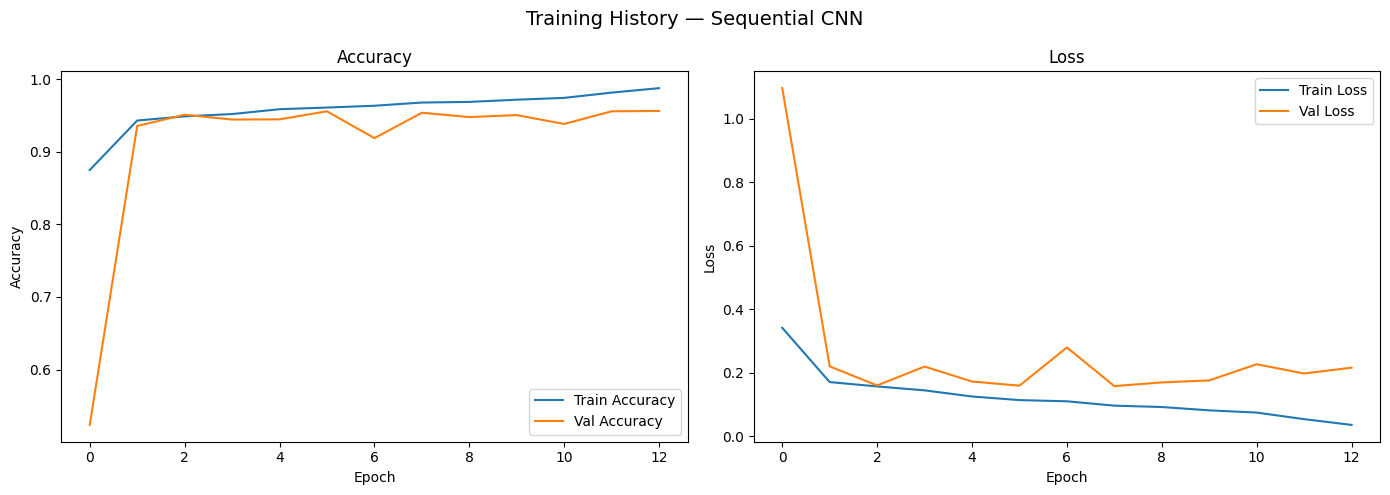

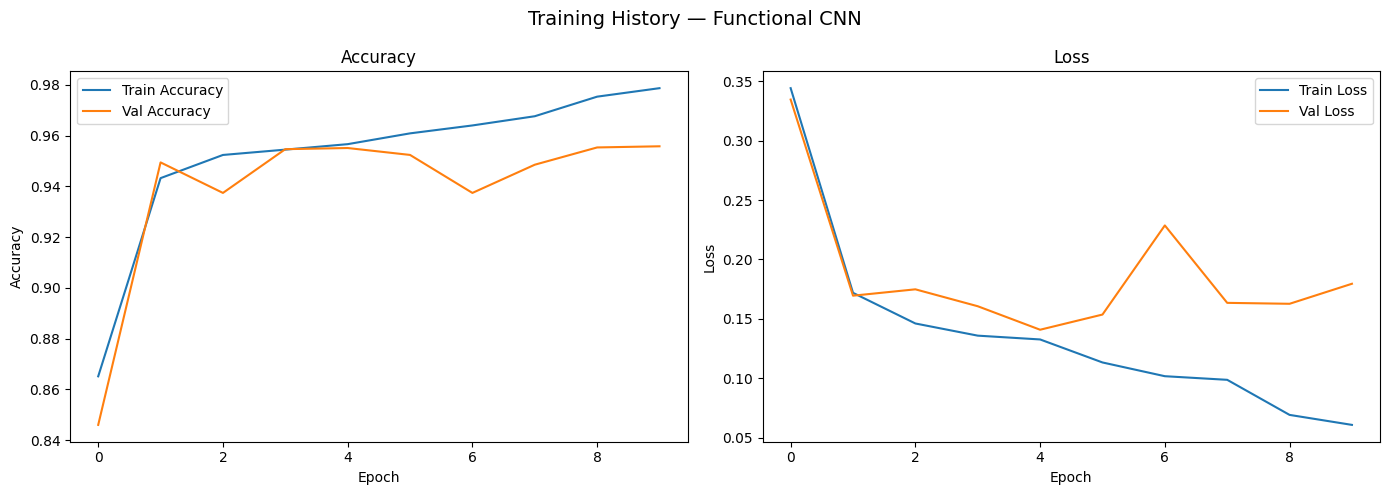

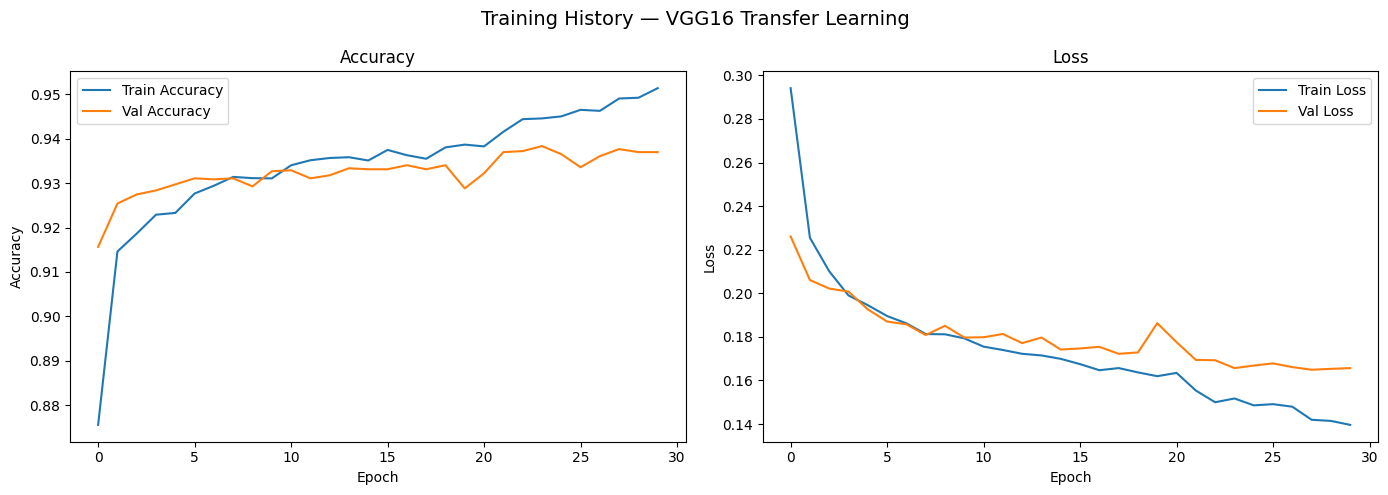

In [24]:
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Training History — {model_name}", fontsize=14)

    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"history_{model_name.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(sequential_history, "Sequential CNN")
plot_training_history(functional_history, "Functional CNN")
plot_training_history(vgg16_history,      "VGG16 Transfer Learning")



## Section 7 — Model Evaluation

All models are evaluated on the test set using the following metrics:

- **Accuracy** — overall percentage of correct predictions
- **Precision** — of all cells predicted as parasitized, how many actually were
- **Recall** — of all actually parasitized cells, how many the model correctly identified
- **F1 Score** — harmonic mean of precision and recall, useful for balanced datasets
- **AUC-ROC** — measures the model's ability to distinguish between the two classes
- **Confusion Matrix** — breakdown of true positives, false positives, true negatives, and false negatives

### Evaluation Helper Function

In [25]:
def evaluate_model(name, y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"AUC-ROC   : {roc_auc:.4f}")

    return {
        "Model"    : name,
        "Accuracy" : round(acc, 4),
        "Precision": round(prec, 4),
        "Recall"   : round(rec, 4),
        "F1 Score" : round(f1, 4),
        "AUC-ROC"  : round(roc_auc, 4)
    }

### Evaluating All Models

In [26]:
results = []

# Random Forest
rf_probs = rf_model.predict_proba(X_test_flat)[:, 1]
results.append(evaluate_model("Random Forest", y_test, rf_preds, rf_probs))

# SVM
svm_probs = svm_model.predict_proba(X_test_flat)[:, 1]
results.append(evaluate_model("SVM", y_test, svm_preds, svm_probs))

# Sequential CNN
seq_probs = sequential_cnn.predict(X_test).flatten()
seq_preds = (seq_probs > 0.5).astype(int)
results.append(evaluate_model("Sequential CNN", y_test, seq_preds, seq_probs))

# Functional CNN
func_probs = functional_cnn.predict(X_test).flatten()
func_preds = (func_probs > 0.5).astype(int)
results.append(evaluate_model("Functional CNN", y_test, func_preds, func_probs))

# VGG16
vgg_probs = vgg16_model.predict(X_test).flatten()
vgg_preds = (vgg_probs > 0.5).astype(int)
results.append(evaluate_model("VGG16 Transfer Learning", y_test, vgg_preds, vgg_probs))


Random Forest
----------------------------------------
Accuracy  : 0.8135
Precision : 0.8349
Recall    : 0.7816
F1 Score  : 0.8073
AUC-ROC   : 0.8939

SVM
----------------------------------------
Accuracy  : 0.7074
Precision : 0.7017
Recall    : 0.7213
F1 Score  : 0.7114
AUC-ROC   : 0.7766
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Sequential CNN
----------------------------------------
Accuracy  : 0.9539
Precision : 0.9356
Recall    : 0.9750
F1 Score  : 0.9549
AUC-ROC   : 0.9868
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Functional CNN
----------------------------------------
Accuracy  : 0.9570
Precision : 0.9424
Recall    : 0.9735
F1 Score  : 0.9577
AUC-ROC   : 0.9884
173/173 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step

VGG16 Transfer Learning
----------------------------------------
Accuracy  : 0.9343
Precision : 0.9200
Recall    : 0.9514
F1 Score  : 0.9354
AUC-ROC   : 0.9833


### Results Comparison Table

In [27]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1 Score", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

                  Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
         Functional CNN    0.9570     0.9424  0.9735    0.9577   0.9884
         Sequential CNN    0.9539     0.9356  0.9750    0.9549   0.9868
VGG16 Transfer Learning    0.9343     0.9200  0.9514    0.9354   0.9833
          Random Forest    0.8135     0.8349  0.7816    0.8073   0.8939
                    SVM    0.7074     0.7017  0.7213    0.7114   0.7766


### Visual Comparison of All Models

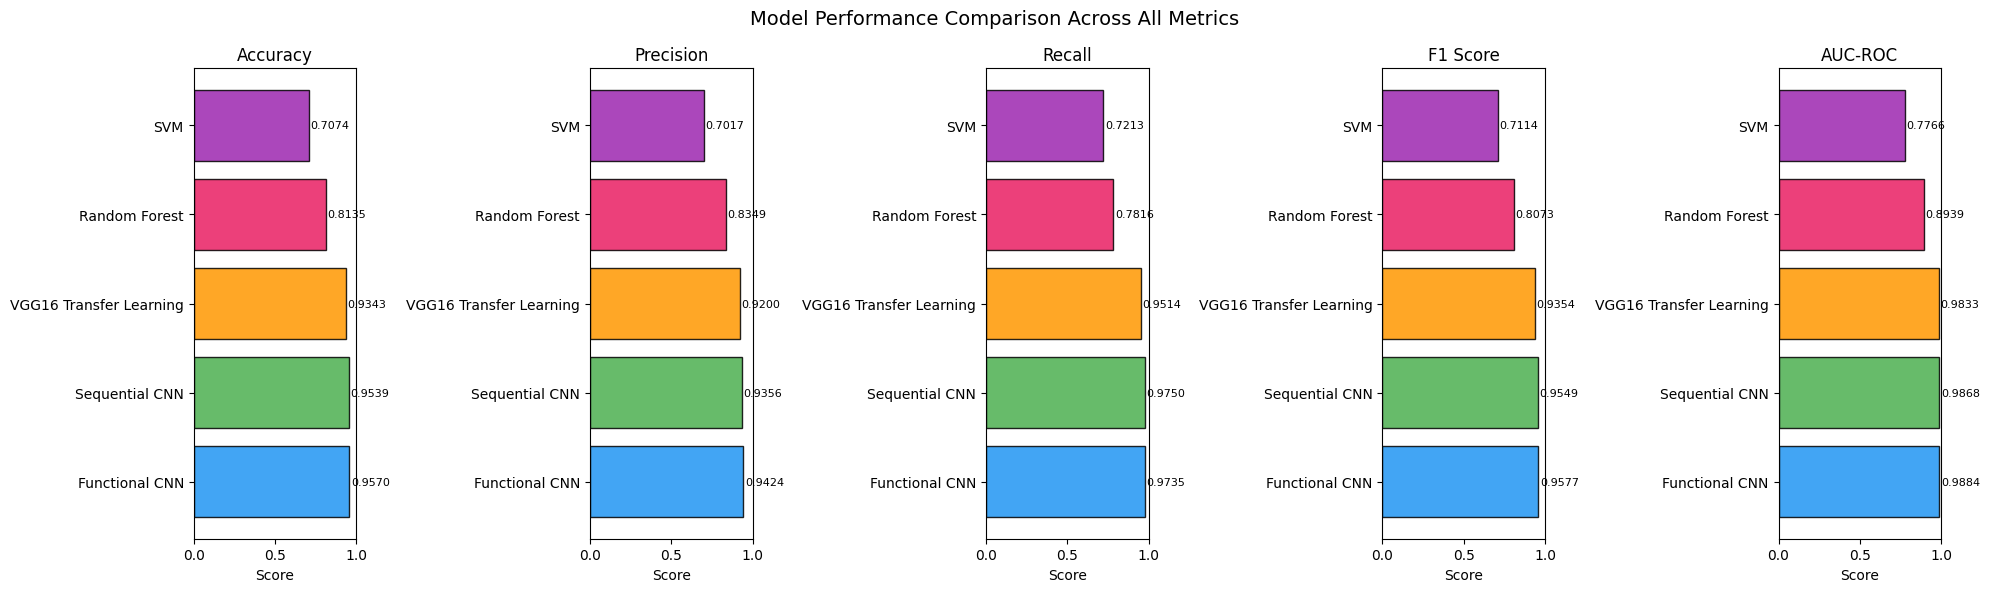

In [28]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 6))
fig.suptitle("Model Performance Comparison Across All Metrics", fontsize=14)

for ax, metric in zip(axes, metrics):
    ax.barh(
        results_df["Model"],
        results_df[metric],
        color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0'],
        edgecolor='black',
        alpha=0.85
    )
    ax.set_xlim(0, 1)
    ax.set_title(metric)
    ax.set_xlabel("Score")
    for i, val in enumerate(results_df[metric]):
        ax.text(val + 0.01, i, f"{val:.4f}", va='center', fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

### Combined ROC Curve

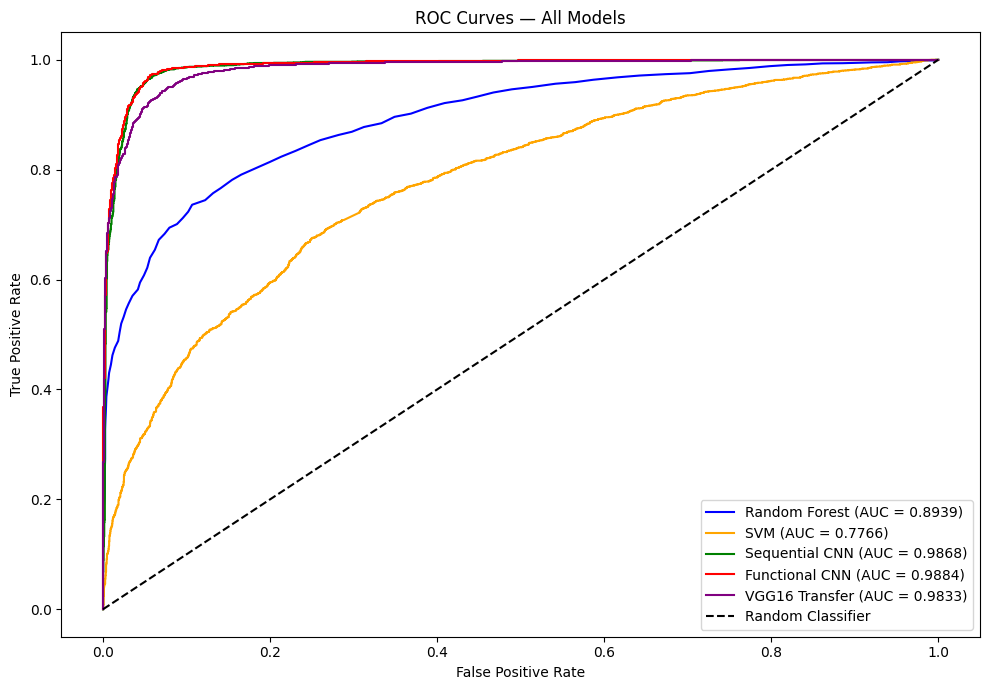

In [29]:
plt.figure(figsize=(10, 7))

models_eval = [
    ("Random Forest",        y_test, rf_probs),
    ("SVM",                  y_test, svm_probs),
    ("Sequential CNN",       y_test, seq_probs),
    ("Functional CNN",       y_test, func_probs),
    ("VGG16 Transfer",       y_test, vgg_probs),
]

colors = ['blue', 'orange', 'green', 'red', 'purple']

for (name, y_true, y_prob), color in zip(models_eval, colors):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})", color=color)

plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("combined_roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()

### Confusion Matrices for All Models

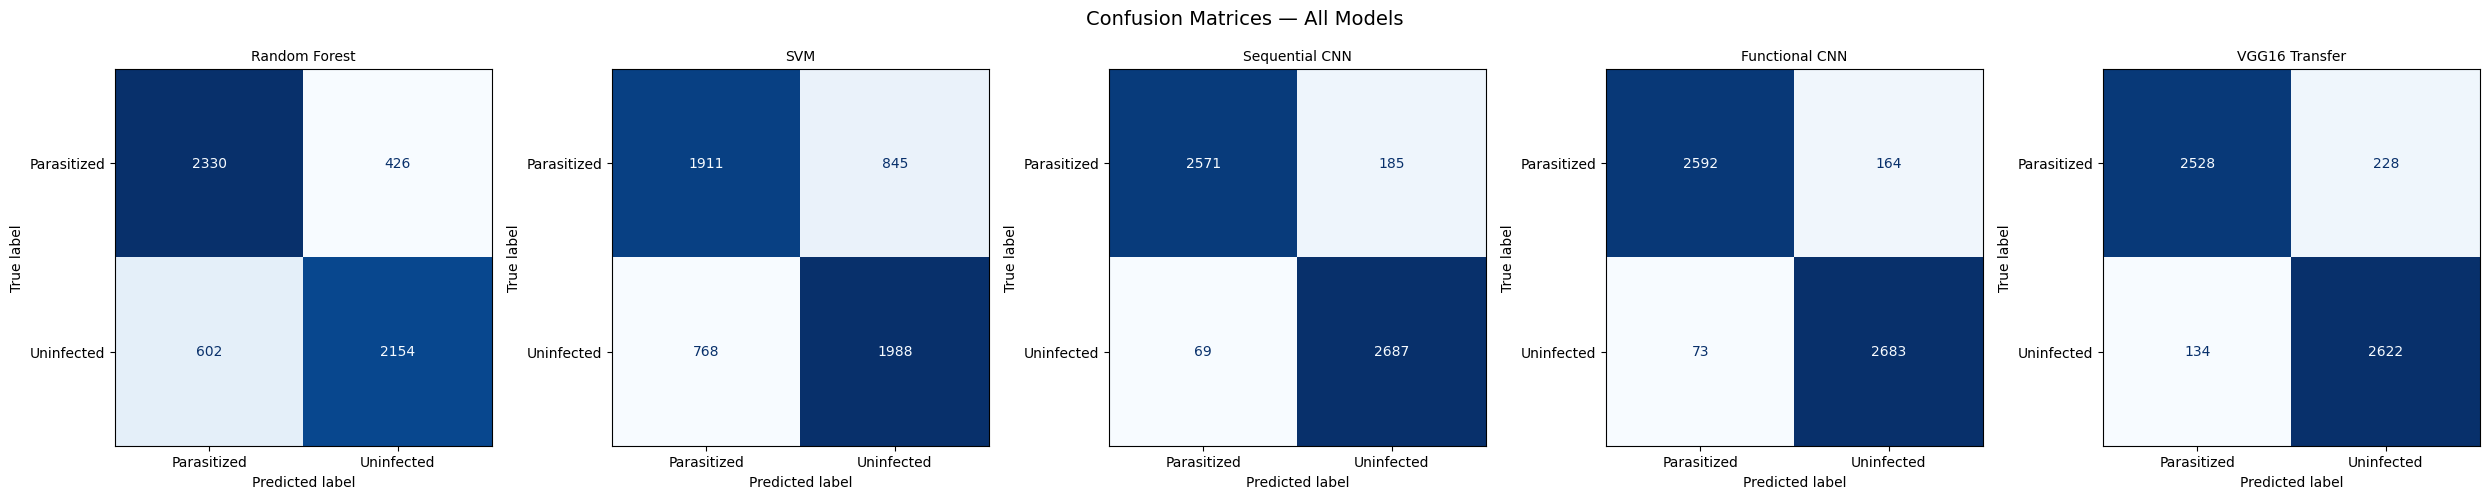

In [30]:
all_preds = [rf_preds, svm_preds, seq_preds, func_preds, vgg_preds]
all_names = ["Random Forest", "SVM", "Sequential CNN", "Functional CNN", "VGG16 Transfer"]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle("Confusion Matrices — All Models", fontsize=14)

for ax, preds, name in zip(axes, all_preds, all_names):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.savefig("all_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

---

## Best Model Selection and Final Save

The model with the highest F1 Score is selected as the best model. All models and preprocessed data are saved to the saved/ folder for use in the API and deployment pipeline.

In [31]:


os.makedirs("saved", exist_ok=True)

# Save preprocessed data
np.save("saved/X_train.npy", X_train)
np.save("saved/X_test.npy", X_test)
np.save("saved/y_train.npy", y_train)
np.save("saved/y_test.npy", y_test)
np.save("saved/X_train_flat.npy", X_train_flat)
np.save("saved/X_test_flat.npy", X_test_flat)
print("Preprocessed data saved.")

# Save traditional ML models
joblib.dump(rf_model, "saved/rf_model.pkl")
print("Random Forest saved.")

joblib.dump(svm_model, "saved/svm_model.pkl")
print("SVM saved.")

# Save deep learning models
sequential_cnn.save("saved/sequential_cnn.h5")
print("Sequential CNN saved.")

functional_cnn.save("saved/functional_cnn.h5")
print("Functional CNN saved.")

vgg16_model.save("saved/vgg16_model.h5")
print("VGG16 saved.")

# Print best model
best_row = results_df.iloc[0]
print("\nBest Model Results")
print("-" * 40)
print(results_df.to_string(index=False))
print(f"\nBest model based on F1 Score: {best_row['Model']}")
print(f"F1 Score  : {best_row['F1 Score']}")
print(f"Accuracy  : {best_row['Accuracy']}")
print(f"AUC-ROC   : {best_row['AUC-ROC']}")
print("\nAll models and data saved to the saved/ folder.")


Preprocessed data saved.
Random Forest saved.


SVM saved.
Sequential CNN saved.
Functional CNN saved.
VGG16 saved.

Best Model Results
----------------------------------------
                  Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
         Functional CNN    0.9570     0.9424  0.9735    0.9577   0.9884
         Sequential CNN    0.9539     0.9356  0.9750    0.9549   0.9868
VGG16 Transfer Learning    0.9343     0.9200  0.9514    0.9354   0.9833
          Random Forest    0.8135     0.8349  0.7816    0.8073   0.8939
                    SVM    0.7074     0.7017  0.7213    0.7114   0.7766

Best model based on F1 Score: Functional CNN
F1 Score  : 0.9577
Accuracy  : 0.957
AUC-ROC   : 0.9884

All models and data saved to the saved/ folder.


In [32]:
import os
import joblib
import numpy as np

# Create the saved folder
os.makedirs("/kaggle/working/saved", exist_ok=True)

# Save preprocessed data
np.save("/kaggle/working/saved/X_train.npy", X_train)
np.save("/kaggle/working/saved/X_test.npy", X_test)
np.save("/kaggle/working/saved/y_train.npy", y_train)
np.save("/kaggle/working/saved/y_test.npy", y_test)
np.save("/kaggle/working/saved/X_train_flat.npy", X_train_flat)
np.save("/kaggle/working/saved/X_test_flat.npy", X_test_flat)
print("Preprocessed data saved.")

# Save traditional ML models
joblib.dump(rf_model, "/kaggle/working/saved/rf_model.pkl")
print("Random Forest saved.")

joblib.dump(svm_model, "/kaggle/working/saved/svm_model.pkl")
print("SVM saved.")

# Save deep learning models
sequential_cnn.save("/kaggle/working/saved/sequential_cnn.h5")
print("Sequential CNN saved.")

functional_cnn.save("/kaggle/working/saved/functional_cnn.h5")
print("Functional CNN saved.")

vgg16_model.save("/kaggle/working/saved/vgg16_model.h5")
print("VGG16 saved.")

# Confirm files exist
print("\nFiles saved:")
for f in os.listdir("/kaggle/working/saved"):
    size = os.path.getsize(f"/kaggle/working/saved/{f}") / (1024 * 1024)
    print(f"  {f} — {size:.2f} MB")

Preprocessed data saved.
Random Forest saved.


SVM saved.
Sequential CNN saved.
Functional CNN saved.
VGG16 saved.

Files saved:
  y_train.npy — 0.08 MB
  X_test.npy — 258.38 MB
  X_train_flat.npy — 1033.41 MB
  X_test_flat.npy — 258.38 MB
  vgg16_model.h5 — 57.71 MB
  X_train.npy — 1033.41 MB
  rf_model.pkl — 27.41 MB
  sequential_cnn.h5 — 14.65 MB
  y_test.npy — 0.02 MB
  svm_model.pkl — 353.98 MB
  functional_cnn.h5 — 14.65 MB
